<a href="https://colab.research.google.com/github/Ziadnasser1/Deep-Learning-Training/blob/main/NLP/SentimentAnalysis_with_different_1DCNNArchitectue.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
lakshmi25npathi_imdb_dataset_of_50k_movie_reviews_path = kagglehub.dataset_download('lakshmi25npathi/imdb-dataset-of-50k-movie-reviews')

print('Data source import complete.')


# Importing Required Libraries

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, Conv1D, GlobalMaxPooling1D, Dense, Concatenate, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import gensim.downloader as api
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

2025-04-30 19:16:16.229209: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746040576.436391      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746040576.497340      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [ ]:
print("Downloading NLTK resources...")
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

# Load the IMDB Reviews dataset

In [ ]:
df = pd.read_csv('/kaggle/input/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


#

# Checking the dataset

In [ ]:
print(df.isnull().sum().sum())

0


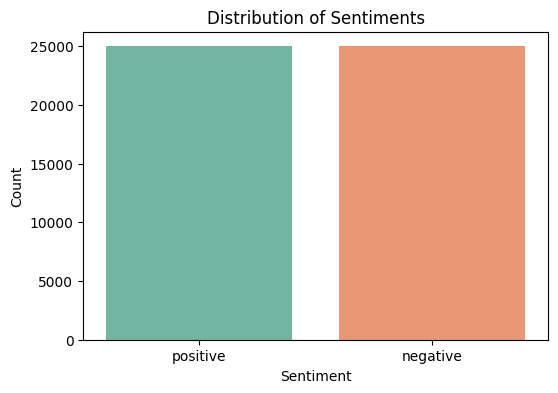

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='sentiment', palette='Set2')
plt.title('Distribution of Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

# Initialize the NLTK tools

In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [ ]:
def preprocess_text(text):
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove special characters and digits
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Convert to lowercase
    text = text.lower()

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stopwords and lemmatize
    cleaned_tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]

    # Join tokens back into text
    cleaned_text = ' '.join(cleaned_tokens)

    return cleaned_text

# Preprocess text in review

In [ ]:
df['review'] = df['review'].apply(preprocess_text)

In [ ]:
df['sentiment'] = df['sentiment'].map({'positive': 1, 'negative': 0})

In [ ]:
df.head()

,review,sentiment
0,one reviewer mentioned watching oz episode you...,1
1,wonderful little production filming technique ...,1
2,thought wonderful way spend time hot summer we...,1
3,basically there family little boy jake think t...,0
4,petter matteis love time money visually stunni...,1


# Split the data

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    df['review'].values,
    df['sentiment'].values,
    test_size=0.2,
    random_state=42
)

In [ ]:
max_words = 10000
max_sequence_length = 200

# Applying Tokenizer

In [ ]:
tokenizer = Tokenizer(num_words=max_words, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)

# Generating Sequences

In [ ]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

In [ ]:
X_train_pad = pad_sequences(X_train_seq, maxlen=max_sequence_length, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=max_sequence_length, padding='post', truncating='post')

# Downloading google word2vec model

In [ ]:
try:
    word2vec_model = api.load('word2vec-google-news-300')
    embedding_dim = 300
    print("Using Google News word2vec model")
except Exception as e:
    print(f"Error loading Google News model: {e}")
    print("Using smaller glove model instead")
    word2vec_model = api.load('glove-wiki-gigaword-100')
    embedding_dim = 100

[===============-----------------------------------] 30.2% 502.4/1662.8MB downloaded

IOPub message rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_msg_rate_limit`.

Current values:
NotebookApp.iopub_msg_rate_limit=10000.0 (msgs/sec)
NotebookApp.rate_limit_window=1.0 (secs)



[===================-------------------------------] 38.8% 645.2/1662.8MB downloaded

IOPub message rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_msg_rate_limit`.

Current values:
NotebookApp.iopub_msg_rate_limit=10000.0 (msgs/sec)
NotebookApp.rate_limit_window=1.0 (secs)



[=======================---------------------------] 47.7% 793.8/1662.8MB downloaded

In [ ]:
word_index = tokenizer.word_index
embedding_matrix = np.zeros((min(max_words, len(word_index) + 1), embedding_dim))

# Generating Embeddings

In [ ]:
for word, i in word_index.items():
    if i >= max_words:
        continue
    try:
        embedding_vector = word2vec_model[word]
        embedding_matrix[i] = embedding_vector
    except KeyError:
        # Words not in embedding index will be all zeros
        pass

# CNN models

In [ ]:
# Function to build CNN model with the specified architecture
def build_cnn_model(filter_sizes, embedding_matrix, max_words, max_sequence_length, embedding_dim):
    model = Sequential()

    # Add embedding layer - specify input_shape
    model.add(Embedding(
        input_dim=min(max_words, len(word_index) + 1),
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=max_sequence_length,
        trainable=False
    ))

    # Create a parallel architecture using functional API
    inputs = tf.keras.Input(shape=(max_sequence_length,))
    embedding = Embedding(
        input_dim=min(max_words, len(word_index) + 1),
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=max_sequence_length,
        trainable=False
    )(inputs)

    # Apply Conv1D layers in parallel, matching the architecture from the image
    conv_outputs = []
    for size in filter_sizes:
        conv = Conv1D(filters=128, kernel_size=size, activation='relu', padding='valid')(embedding)
        pool = GlobalMaxPooling1D()(conv)
        conv_outputs.append(pool)

    # Concatenate outputs if we have multiple conv layers
    if len(conv_outputs) > 1:
        concatenated = tf.keras.layers.Concatenate()(conv_outputs)
    else:
        concatenated = conv_outputs[0]

    # Add dropout and dense layers
    x = Dropout(0.5)(concatenated)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(64, activation='relu')(x)
    outputs = Dense(1, activation='sigmoid')(x)

    # Create the model
    model = tf.keras.Model(inputs=inputs, outputs=outputs)

    # Compile the model
    model.compile(
        loss='binary_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )

    return model

# Training Different CNN models with different kernels


Training Model 1 with filter sizes [2, 3, 4]
Model 1 Summary:


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5             │ (None, 200)            │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ embedding_6 (Embedding)   │ (None, 200, 300)       │      3,000,000 │ input_layer_5[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_15 (Conv1D)        │ (None, 199, 128)       │         76,928 │ embedding_6[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_16 (Conv1D)        │ (None, 198, 128)       │        115,328 │ embedding_6[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_17 (Conv1D)        │ (None, 197, 128)       │        153,728 │ embedding_6[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_max_pooling1d_13   │ (None, 128)            │              0 │ conv1d_15[0][0]        │
│ (GlobalMaxPooling1D)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_max_pooling1d_14   │ (None, 128)            │              0 │ conv1d_16[0][0]        │
│ (GlobalMaxPooling1D)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_max_pooling1d_15   │ (None, 128)            │              0 │ conv1d_17[0][0]        │
│ (GlobalMaxPooling1D)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_4             │ (None, 384)            │              0 │ global_max_pooling1d_… │
│ (Concatenate)             │                        │                │ global_max_pooling1d_… │
│                           │                        │                │ global_max_pooling1d_… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_6 (Dropout)       │ (None, 384)            │              0 │ concatenate_4[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_7 (Dense)           │ (None, 128)            │         49,280 │ dropout_6[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_7 (Dropout)       │ (None, 128)            │              0 │ dense_7[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_8 (Dense)           │ (None, 64)             │          8,256 │ dropout_7[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_9 (Dense)           │ (None, 1)              │             65 │ dense_8[0][0]          │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 3,403,585 (12.98 MB)

 Trainable params: 403,585 (1.54 MB)

 Non-trainable params: 3,000,000 (11.44 MB)

Epoch 1/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 13s 15ms/step - accuracy: 0.6579 - loss: 0.5839 - val_accuracy: 0.8660 - val_loss: 0.3296
Epoch 2/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8467 - loss: 0.3594 - val_accuracy: 0.8763 - val_loss: 0.2964
Epoch 3/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8697 - loss: 0.3123 - val_accuracy: 0.8855 - val_loss: 0.2753
Epoch 4/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.8922 - loss: 0.2666 - val_accuracy: 0.8890 - val_loss: 0.2700
Epoch 5/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9021 - loss: 0.2386 - val_accuracy: 0.8820 - val_loss: 0.2727
Epoch 6/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9187 - loss: 0.2081 - val_accuracy: 0.8815 - val_loss: 0.2800
Epoch 7/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9249 - loss: 0.1823 - val_accuracy: 0.8857 - val_loss: 0.2839
Model 1 Test Accuracy: 0.8796
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


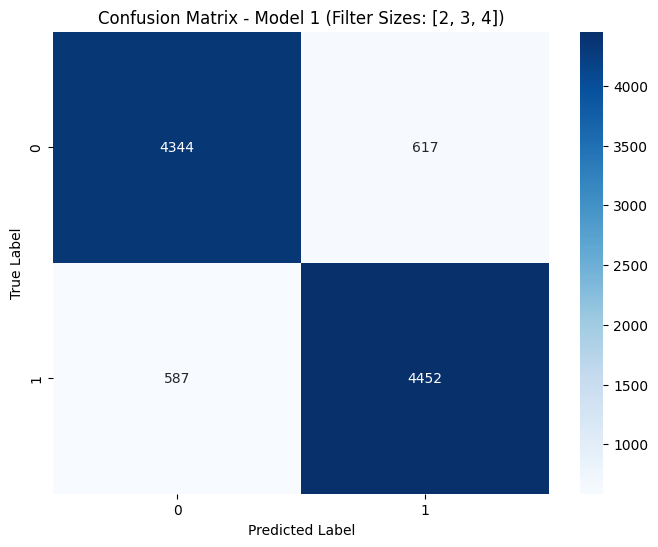


Training Model 2 with filter sizes [3, 4, 5]
Model 2 Summary:


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6             │ (None, 200)            │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ embedding_8 (Embedding)   │ (None, 200, 300)       │      3,000,000 │ input_layer_6[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_18 (Conv1D)        │ (None, 198, 128)       │        115,328 │ embedding_8[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_19 (Conv1D)        │ (None, 197, 128)       │        153,728 │ embedding_8[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_20 (Conv1D)        │ (None, 196, 128)       │        192,128 │ embedding_8[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_max_pooling1d_16   │ (None, 128)            │              0 │ conv1d_18[0][0]        │
│ (GlobalMaxPooling1D)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_max_pooling1d_17   │ (None, 128)            │              0 │ conv1d_19[0][0]        │
│ (GlobalMaxPooling1D)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_max_pooling1d_18   │ (None, 128)            │              0 │ conv1d_20[0][0]        │
│ (GlobalMaxPooling1D)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_5             │ (None, 384)            │              0 │ global_max_pooling1d_… │
│ (Concatenate)             │                        │                │ global_max_pooling1d_… │
│                           │                        │                │ global_max_pooling1d_… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_8 (Dropout)       │ (None, 384)            │              0 │ concatenate_5[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_10 (Dense)          │ (None, 128)            │         49,280 │ dropout_8[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_9 (Dropout)       │ (None, 128)            │              0 │ dense_10[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_11 (Dense)          │ (None, 64)             │          8,256 │ dropout_9[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_12 (Dense)          │ (None, 1)              │             65 │ dense_11[0][0]         │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 3,518,785 (13.42 MB)

 Trainable params: 518,785 (1.98 MB)

 Non-trainable params: 3,000,000 (11.44 MB)

Epoch 1/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.6716 - loss: 0.5734 - val_accuracy: 0.8720 - val_loss: 0.3176
Epoch 2/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8487 - loss: 0.3484 - val_accuracy: 0.8790 - val_loss: 0.2916
Epoch 3/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8738 - loss: 0.3013 - val_accuracy: 0.8817 - val_loss: 0.2844
Epoch 4/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8940 - loss: 0.2598 - val_accuracy: 0.8855 - val_loss: 0.2766
Epoch 5/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9110 - loss: 0.2214 - val_accuracy: 0.8798 - val_loss: 0.2827
Epoch 6/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9251 - loss: 0.1919 - val_accuracy: 0.8817 - val_loss: 0.2965
Epoch 7/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9378 - loss: 0.1589 - val_accuracy: 0.8827 - val_loss: 0.3169
Model 2 Test Accuracy: 0.8762
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


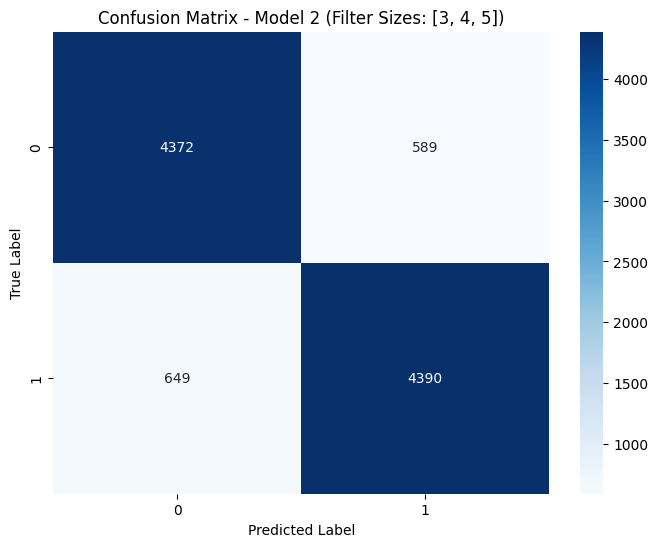


Training Model 3 with filter sizes [4, 5, 6]
Model 3 Summary:


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7             │ (None, 200)            │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ embedding_10 (Embedding)  │ (None, 200, 300)       │      3,000,000 │ input_layer_7[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_21 (Conv1D)        │ (None, 197, 128)       │        153,728 │ embedding_10[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_22 (Conv1D)        │ (None, 196, 128)       │        192,128 │ embedding_10[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1d_23 (Conv1D)        │ (None, 195, 128)       │        230,528 │ embedding_10[0][0]     │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_max_pooling1d_19   │ (None, 128)            │              0 │ conv1d_21[0][0]        │
│ (GlobalMaxPooling1D)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_max_pooling1d_20   │ (None, 128)            │              0 │ conv1d_22[0][0]        │
│ (GlobalMaxPooling1D)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_max_pooling1d_21   │ (None, 128)            │              0 │ conv1d_23[0][0]        │
│ (GlobalMaxPooling1D)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate_6             │ (None, 384)            │              0 │ global_max_pooling1d_… │
│ (Concatenate)             │                        │                │ global_max_pooling1d_… │
│                           │                        │                │ global_max_pooling1d_… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_10 (Dropout)      │ (None, 384)            │              0 │ concatenate_6[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_13 (Dense)          │ (None, 128)            │         49,280 │ dropout_10[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_11 (Dropout)      │ (None, 128)            │              0 │ dense_13[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_14 (Dense)          │ (None, 64)             │          8,256 │ dropout_11[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense_15 (Dense)          │ (None, 1)              │             65 │ dense_14[0][0]         │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 3,633,985 (13.86 MB)

 Trainable params: 633,985 (2.42 MB)

 Non-trainable params: 3,000,000 (11.44 MB)

Epoch 1/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.6719 - loss: 0.5703 - val_accuracy: 0.8692 - val_loss: 0.3139
Epoch 2/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8495 - loss: 0.3544 - val_accuracy: 0.8785 - val_loss: 0.2942
Epoch 3/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8751 - loss: 0.2978 - val_accuracy: 0.8805 - val_loss: 0.2849
Epoch 4/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8996 - loss: 0.2477 - val_accuracy: 0.8817 - val_loss: 0.2811
Epoch 5/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9176 - loss: 0.2108 - val_accuracy: 0.8820 - val_loss: 0.2903
Epoch 6/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9329 - loss: 0.1782 - val_accuracy: 0.8817 - val_loss: 0.3014
Epoch 7/10
563/563 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.9445 - loss: 0.1468 - val_accuracy: 0.8810 - val_loss: 0.3161
Model 3 Test Accuracy: 0.8741
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


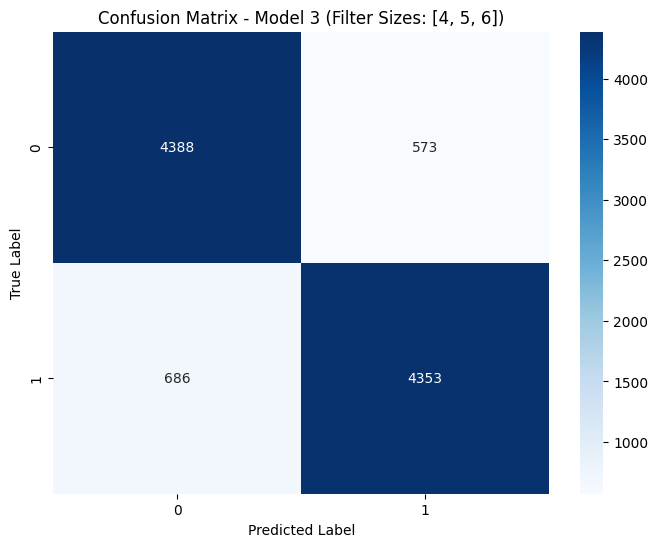

In [ ]:
from tensorflow.keras.models import Sequential
kernel_sizes_options = [
    [2, 3, 4],  # First model
    [3, 4, 5],  # Second model
    [4, 5, 6]   # Third model
]

# Train and evaluate each model
results = []
models = []
histories = []

for i, filter_sizes in enumerate(kernel_sizes_options):
    print(f"\nTraining Model {i+1} with filter sizes {filter_sizes}")

    # Create model
    model = build_cnn_model(
        filter_sizes=filter_sizes,
        embedding_matrix=embedding_matrix,
        max_words=max_words,
        max_sequence_length=max_sequence_length,
        embedding_dim=embedding_dim
    )

    # Print model summary
    print(f"Model {i+1} Summary:")
    model.summary()

    # Early stopping
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )

    # Train model
    history = model.fit(
        X_train_pad, y_train,
        validation_split=0.1,
        epochs=10,
        batch_size=64,
        callbacks=[early_stopping],
        verbose=1
    )

    histories.append(history)

    # Evaluate model
    loss, accuracy = model.evaluate(X_test_pad, y_test, verbose=0)
    print(f"Model {i+1} Test Accuracy: {accuracy:.4f}")

    # Predictions
    y_pred = (model.predict(X_test_pad) > 0.5).astype(int)

    # Classification report
    report = classification_report(y_test, y_pred, output_dict=True)

    # Save results
    results.append({
        'model_num': i+1,
        'filter_sizes': filter_sizes,
        'accuracy': accuracy,
        'f1_score': report['weighted avg']['f1-score'],
        'precision': report['weighted avg']['precision'],
        'recall': report['weighted avg']['recall']
    })

    models.append(model)

    # Plot confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - Model {i+1} (Filter Sizes: {filter_sizes})')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

# Saving the 3 Models numbers

In [ ]:
results_df = pd.DataFrame(results)
print("\nModel Comparison:")
print(results_df)

# Find the best model
best_model_idx = results_df['accuracy'].idxmax()
best_model = models[best_model_idx]
best_filter_sizes = kernel_sizes_options[best_model_idx]
best_history = histories[best_model_idx]

print(f"\nBest Model: Model {best_model_idx + 1} with filter sizes {best_filter_sizes}")
print(f"Best Model Accuracy: {results_df.iloc[best_model_idx]['accuracy']:.4f}")
print(f"Best Model F1 Score: {results_df.iloc[best_model_idx]['f1_score']:.4f}")

# Save the best model
best_model.save('best_cnn_sentiment_model.h5')
print("Best model saved as 'best_cnn_sentiment_model.h5'")


Model Comparison:
   model_num filter_sizes  accuracy  f1_score  precision  recall kernel_sizes
0          1    [2, 3, 4]    0.8796  0.879596   0.879608  0.8796          NaN
1          2    [3, 4, 5]    0.8762  0.876201   0.876266  0.8762          NaN
2          3    [4, 5, 6]    0.8741  0.874095   0.874313  0.8741          NaN
3          3          NaN    0.8741  0.874095   0.874313  0.8741    [4, 5, 6]

Best Model: Model 1 with filter sizes [2, 3, 4]
Best Model Accuracy: 0.8796
Best Model F1 Score: 0.8796
Best model saved as 'best_cnn_sentiment_model.h5'


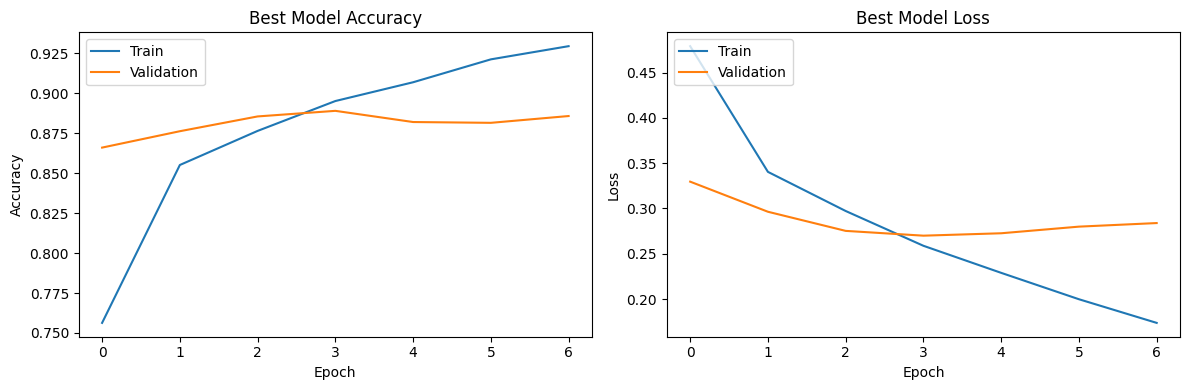

In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(best_history.history['accuracy'])
plt.plot(best_history.history['val_accuracy'])
plt.title('Best Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.subplot(1, 2, 2)
plt.plot(best_history.history['loss'])
plt.plot(best_history.history['val_loss'])
plt.title('Best Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.tight_layout()
plt.show()

# Predicting sentiment

In [ ]:
def predict_sentiment(text, model, tokenizer):
    # Clean and preprocess
    cleaned_text = preprocess_text(text)
    # Tokenize and pad
    sequence = tokenizer.texts_to_sequences([cleaned_text])
    padded = pad_sequences(sequence, maxlen=max_sequence_length, padding='post', truncating='post')
    # Predict
    prediction = model.predict(padded)[0][0]
    sentiment = "Positive" if prediction > 0.5 else "Negative"
    confidence = prediction if prediction > 0.5 else 1 - prediction
    return sentiment, confidence

In [ ]:
example_reviews = [
    "This movie was absolutely fantastic! The acting was superb and the plot was engaging.",
    "I hated every minute of this film. The characters were poorly developed and the story made no sense.",
    "It was okay. Not great, not terrible, just average entertainment."
]

print("\nTesting with example reviews:")
for review in example_reviews:
    sentiment, confidence = predict_sentiment(review, best_model, tokenizer)
    print(f"Review: {review[:50]}...")
    print(f"Predicted sentiment: {sentiment} (confidence: {confidence:.2f})\n")


Testing with example reviews:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step
Review: This movie was absolutely fantastic! The acting wa...
Predicted sentiment: Positive (confidence: 0.98)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Review: I hated every minute of this film. The characters ...
Predicted sentiment: Negative (confidence: 0.91)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Review: It was okay. Not great, not terrible, just average...
Predicted sentiment: Negative (confidence: 0.66)

